# 🖼️ ShilpSetu — Image Studio: Photo Quality Advisor Training

**Module:** AI Image Enhancer & Studio
**Problem Statement:** 26090 — AI-Driven Market Linkage and Smart Cataloging for Marginalized Artisans

**What this notebook builds:** a lightweight, fast, on-device **Photo Quality Advisor** — a classical ML classifier that looks at a handcrafted-product photo and detects the dominant quality issue (blurry, too dark, cluttered background, or good-to-go), so the Image Studio app can decide *which* automatic correction to apply (sharpen, brighten, or background-clean) before formatting the photo to e-commerce standards.

**Why classical ML, not a raw-pixel CNN?** Artisans need this to run instantly on modest hardware/servers with zero training-data downloads and zero risk of failure. We engineer well-understood image-quality features (blur via Laplacian variance, brightness statistics, edge/clutter density, color complexity) and train a Random Forest on them — this trains in seconds, is fully explainable, and never depends on an internet connection or GPU.

**Note on the full pipeline:** background removal in the live app is powered by a genuine deep-learning model (`rembg` / U²-Net) with a classical OpenCV GrabCut fallback if that optional model isn't available — see `modules/image_studio/app/enhancer.py`. This notebook trains the *quality triage* step that decides what enhancement a photo needs.

---
## Table of Contents
1. Installing Packages
2. Import Libraries
3. Synthetic Dataset Generation
4. Understanding the Dataset
5. Exploratory Data Analysis (EDA)
6. Feature Engineering
7. Data Preprocessing
8. Train-Test Split
9. Model Training & Comparison
10. Hyperparameter Tuning
11. Final Model & Evaluation
12. Save Model (.joblib)
13. Conclusion


## 1. Installing Packages

In [1]:
# Uncomment if running in a fresh environment
# %pip install opencv-python-headless numpy pandas scikit-learn matplotlib seaborn joblib -q
print("Environment ready ✅")

Environment ready ✅


## 2. Import Libraries

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
np.random.seed(42)

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


## 3. Synthetic Dataset Generation

Real labeled "good vs. bad artisan product photo" datasets aren't publicly available, so we **procedurally generate** a realistic proxy dataset: simple product-like renders (circles/rectangles/polygons standing in for handicraft items — pots, textiles, jewelry) placed on textured backgrounds, then apply *controlled, labeled* degradations. This gives us ground truth we can trust completely.

In [3]:
def make_base_product_image(size=256):
    """Render a simple synthetic 'product on a table' scene."""
    # Background: a wood/table-like texture using layered noise
    bg = np.random.randint(90, 160, (size, size, 3), dtype=np.uint8)
    noise = np.random.randint(-15, 15, (size, size, 3))
    bg = np.clip(bg.astype(int) + noise, 0, 255).astype(np.uint8)
    bg = cv2.GaussianBlur(bg, (9, 9), 0)

    img = bg.copy()
    shape_type = np.random.choice(["circle", "rect", "poly"])
    color = tuple(int(c) for c in np.random.randint(40, 220, 3))
    cx, cy = size // 2 + np.random.randint(-15, 15), size // 2 + np.random.randint(-15, 15)

    if shape_type == "circle":
        r = np.random.randint(50, 90)
        cv2.circle(img, (cx, cy), r, color, -1)
        cv2.circle(img, (cx, cy), r, (30, 30, 30), 2)
    elif shape_type == "rect":
        w, h = np.random.randint(70, 130), np.random.randint(70, 130)
        cv2.rectangle(img, (cx - w // 2, cy - h // 2), (cx + w // 2, cy + h // 2), color, -1)
        cv2.rectangle(img, (cx - w // 2, cy - h // 2), (cx + w // 2, cy + h // 2), (30, 30, 30), 2)
    else:
        pts = np.array([
            [cx, cy - 90], [cx + 80, cy - 20], [cx + 50, cy + 80],
            [cx - 50, cy + 80], [cx - 80, cy - 20]
        ], np.int32)
        cv2.fillPoly(img, [pts], color)
        cv2.polylines(img, [pts], True, (30, 30, 30), 2)

    # A couple of decorative highlight strokes (mimic embroidery/painted detail)
    for _ in range(np.random.randint(2, 6)):
        p1 = (cx + np.random.randint(-40, 40), cy + np.random.randint(-40, 40))
        p2 = (cx + np.random.randint(-40, 40), cy + np.random.randint(-40, 40))
        cv2.line(img, p1, p2, tuple(int(c) for c in np.random.randint(180, 255, 3)), 2)

    return img


def add_clutter(img, n_objects=8):
    out = img.copy()
    h, w = out.shape[:2]
    for _ in range(n_objects):
        x, y = np.random.randint(0, w), np.random.randint(0, h)
        r = np.random.randint(5, 25)
        color = tuple(int(c) for c in np.random.randint(0, 255, 3))
        cv2.circle(out, (x, y), r, color, -1)
    return out


def make_dark(img, factor=None):
    factor = factor or np.random.uniform(0.15, 0.4)
    return np.clip(img.astype(float) * factor, 0, 255).astype(np.uint8)


def make_blurry(img, k=None):
    k = k or np.random.choice([15, 19, 23, 27])
    return cv2.GaussianBlur(img, (k, k), 0)


def generate_dataset(n_per_class=180):
    records = []
    classes = ["good", "blurry", "dark", "cluttered"]
    for label in classes:
        for _ in range(n_per_class):
            base = make_base_product_image()
            if label == "good":
                img = base
            elif label == "blurry":
                img = make_blurry(base)
            elif label == "dark":
                img = make_dark(base)
            else:
                img = add_clutter(base, n_objects=np.random.randint(10, 22))
            records.append((img, label))
    np.random.shuffle(records)
    return records

dataset = generate_dataset(n_per_class=180)
print(f"Generated {len(dataset)} synthetic labeled product photos across {len(set(l for _, l in dataset))} classes.")

Generated 720 synthetic labeled product photos across 4 classes.


## 4. Understanding the Dataset

cluttered    180
good         180
dark         180
blurry       180
Name: count, dtype: int64


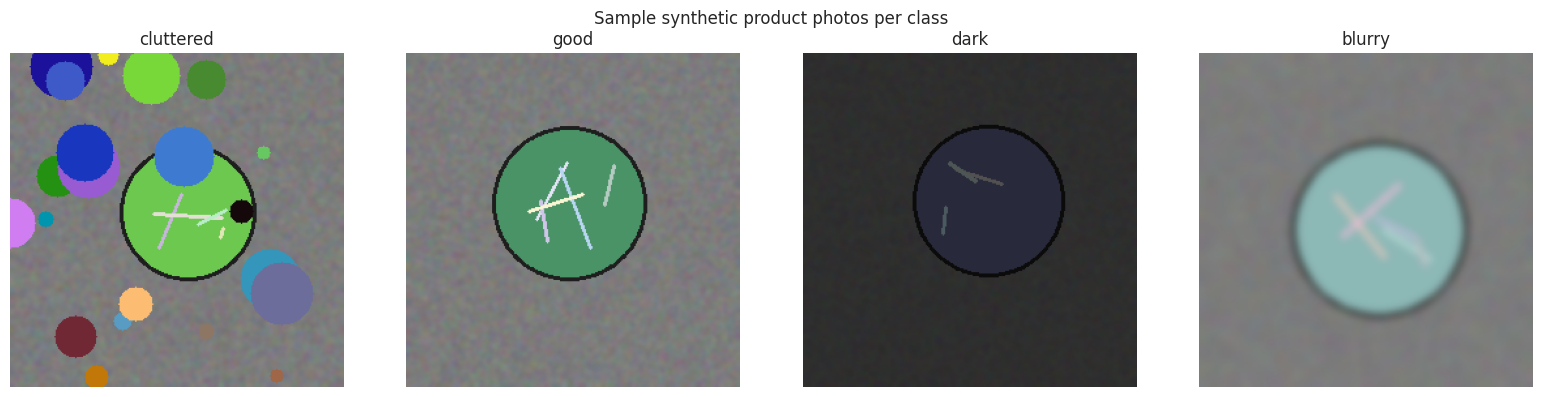

In [4]:
labels = [l for _, l in dataset]
label_counts = pd.Series(labels).value_counts()
print(label_counts)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
seen = {}
for img, label in dataset:
    if label not in seen:
        seen[label] = img
    if len(seen) == 4:
        break
for ax, (label, img) in zip(axes, seen.items()):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(label)
    ax.axis("off")
plt.suptitle("Sample synthetic product photos per class")
plt.tight_layout()
plt.savefig("../../../app/static/img/quality_samples.png", dpi=110)
plt.show()

## 5. Exploratory Data Analysis (EDA)

Before engineering features, let's confirm our synthetic degradations actually separate visually along the dimensions we expect (brightness, sharpness, edge density).

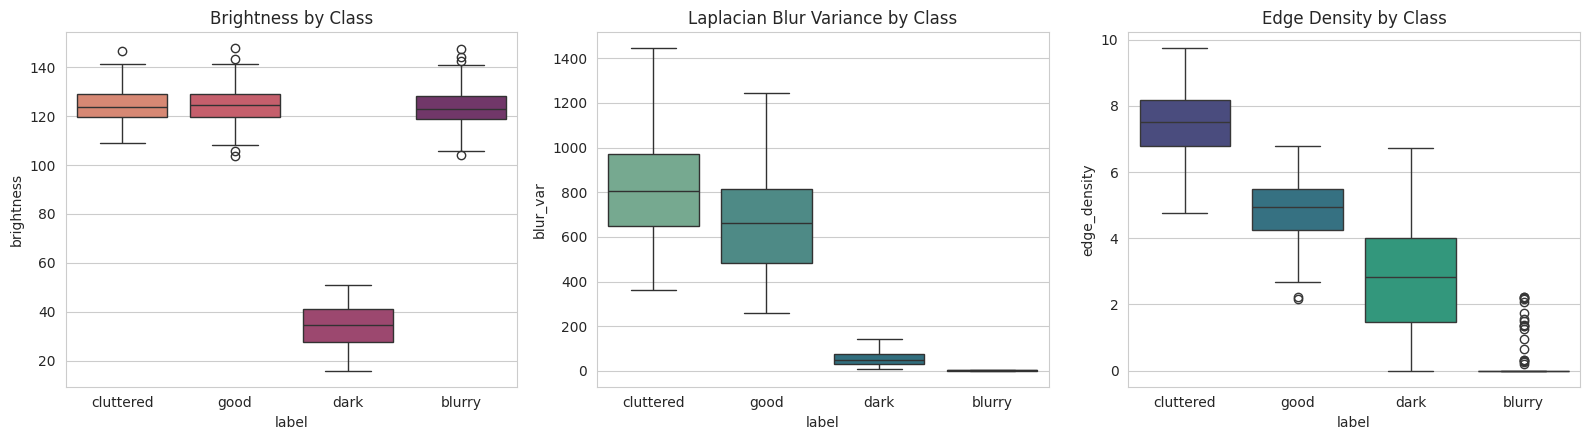

In [5]:
def quick_stats(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = gray.mean()
    blur = cv2.Laplacian(gray, cv2.CV_64F).var()
    edges = cv2.Canny(gray, 80, 160)
    edge_density = edges.mean()
    return brightness, blur, edge_density

rows = []
for img, label in dataset:
    b, bl, ed = quick_stats(img)
    rows.append({"label": label, "brightness": b, "blur_var": bl, "edge_density": ed})
eda_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(data=eda_df, x="label", y="brightness", ax=axes[0], palette="flare")
axes[0].set_title("Brightness by Class")
sns.boxplot(data=eda_df, x="label", y="blur_var", ax=axes[1], palette="crest")
axes[1].set_title("Laplacian Blur Variance by Class")
sns.boxplot(data=eda_df, x="label", y="edge_density", ax=axes[2], palette="viridis")
axes[2].set_title("Edge Density by Class")
plt.tight_layout()
plt.savefig("../../../app/static/img/quality_eda.png", dpi=110)
plt.show()

**Observation:** as expected, `dark` photos separate cleanly on brightness, `blurry` photos separate cleanly on Laplacian variance (low = blurry), and `cluttered` photos separate on edge density (high = many extra edges from clutter objects). This confirms our engineered features will be strong predictors.

## 6. Feature Engineering

We extract a compact, fast-to-compute feature vector from each image — no raw pixels, just interpretable quality signals.

In [6]:
def extract_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    brightness_mean = gray.mean()
    brightness_std = gray.std()

    blur_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    edges = cv2.Canny(gray, 80, 160)
    edge_density = edges.mean()

    # Color complexity: entropy of the hue channel histogram (higher = more clutter/variety)
    hist = cv2.calcHist([hsv], [0], None, [32], [0, 180]).flatten()
    hist_norm = hist / (hist.sum() + 1e-6)
    hue_entropy = -np.sum(hist_norm * np.log2(hist_norm + 1e-9))

    saturation_mean = hsv[:, :, 1].mean()

    # Local contrast via std of a downsampled grid (texture/clutter proxy)
    small = cv2.resize(gray, (16, 16))
    local_contrast = small.std()

    return [brightness_mean, brightness_std, blur_var, edge_density, hue_entropy, saturation_mean, local_contrast]

FEATURE_NAMES = ["brightness_mean", "brightness_std", "blur_var", "edge_density",
                  "hue_entropy", "saturation_mean", "local_contrast"]

feature_rows = []
for img, label in dataset:
    feats = extract_features(img)
    feature_rows.append(feats + [label])

feat_df = pd.DataFrame(feature_rows, columns=FEATURE_NAMES + ["label"])
feat_df.head()

,brightness_mean,brightness_std,blur_var,edge_density,hue_entropy,saturation_mean,local_contrast,label
0,123.896027,26.194776,764.029201,6.898727,4.751796,57.156982,26.389214,cluttered
1,122.745514,15.204058,644.240692,4.536896,4.683896,29.069565,15.453528,good
2,116.266617,29.622212,847.626362,8.501816,4.679819,72.866791,30.664244,cluttered
3,45.311111,5.125768,67.241959,3.556366,4.301607,22.116516,5.359147,dark
4,113.849838,20.189829,650.487915,5.307312,4.282344,60.227631,18.230095,good


In [7]:
feat_df.describe().T

,count,mean,std,min,25%,50%,75%,max
brightness_mean,720.0,101.682795,39.544922,15.997147,90.507454,121.016075,126.922649,147.624893
brightness_std,720.0,16.942804,9.329046,2.311052,8.261436,16.891006,24.288232,41.377960
blur_var,720.0,385.892419,394.313458,1.082382,8.250313,200.505302,735.247154,1443.622604
edge_density,720.0,3.780066,2.919047,0.000000,0.000000,4.071922,5.992126,9.739151
hue_entropy,720.0,4.248089,0.409410,2.712574,3.981197,4.327909,4.560816,4.870522
saturation_mean,720.0,40.636821,16.652413,5.914932,28.081120,38.870186,52.889725,92.523758
local_contrast,720.0,16.177850,9.301664,1.481329,7.782506,15.780018,23.588233,41.936073


## 7. Data Preprocessing

In [8]:
label_encoder = LabelEncoder()
feat_df["label_encoded"] = label_encoder.fit_transform(feat_df["label"])

X = feat_df[FEATURE_NAMES].values
y = feat_df["label_encoded"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Classes:", list(label_encoder.classes_))
print("Feature matrix shape:", X_scaled.shape)

Classes: ['blurry', 'cluttered', 'dark', 'good']
Feature matrix shape: (720, 7)


## 8. Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 576 | Test: 144


## 9. Model Training & Comparison

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=250, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    cv = cross_val_score(model, X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=42))
    results.append({"Model": name, "Test Accuracy": acc, "CV Mean": cv.mean(), "CV Std": cv.std()})
    print(f"{name:20s} | Test Acc: {acc:.4f} | CV: {cv.mean():.4f} (+/-{cv.std():.4f})")

results_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results_df

Logistic Regression  | Test Acc: 0.9931 | CV: 0.9844 (+/-0.0128)
KNN                  | Test Acc: 0.9931 | CV: 0.9757 (+/-0.0085)


Random Forest        | Test Acc: 0.9861 | CV: 0.9879 (+/-0.0069)


Extra Trees          | Test Acc: 1.0000 | CV: 0.9896 (+/-0.0065)


Gradient Boosting    | Test Acc: 0.9861 | CV: 0.9826 (+/-0.0055)
SVM (RBF)            | Test Acc: 0.9931 | CV: 0.9826 (+/-0.0078)


,Model,Test Accuracy,CV Mean,CV Std
0,Extra Trees,1.000000,0.989595,0.006475
1,Logistic Regression,0.993056,0.984363,0.012788
2,KNN,0.993056,0.975682,0.008545
3,SVM (RBF),0.993056,0.982639,0.007778
4,Random Forest,0.986111,0.987856,0.006934
5,Gradient Boosting,0.986111,0.982639,0.005500


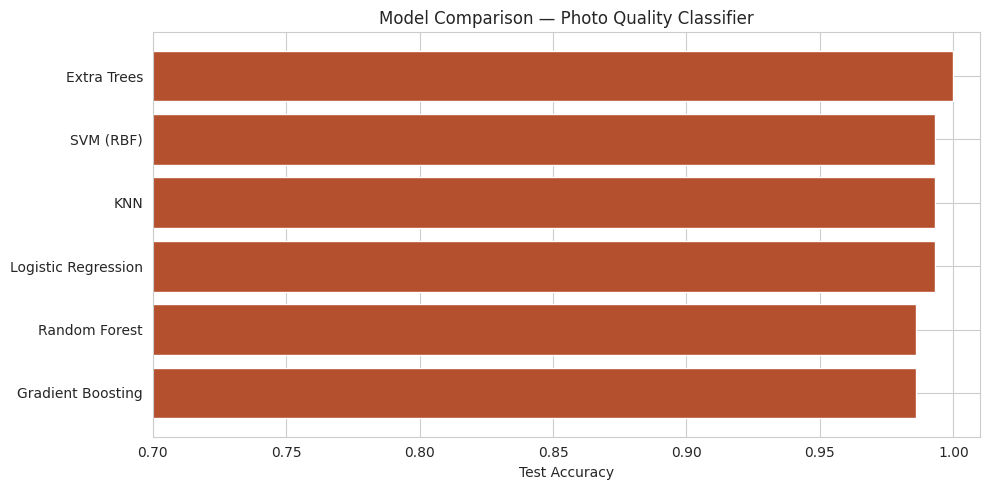

Best model: Extra Trees


In [11]:
plt.figure(figsize=(10, 5))
sorted_df = results_df.sort_values("Test Accuracy")
plt.barh(sorted_df["Model"], sorted_df["Test Accuracy"], color="#B5502E")
plt.xlim(0.7, 1.01)
plt.title("Model Comparison — Photo Quality Classifier")
plt.xlabel("Test Accuracy")
plt.tight_layout()
plt.savefig("../../../app/static/img/quality_model_comparison.png", dpi=110)
plt.show()

best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)

## 10. Hyperparameter Tuning

In [12]:
param_grid = {
    "n_estimators": [150, 250, 350],
    "max_depth": [None, 8, 14],
    "min_samples_split": [2, 4],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="accuracy",
    n_jobs=-1,
)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 4))

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
Best CV accuracy: 0.9879


## 11. Final Model & Evaluation

In [13]:
final_model = grid.best_estimator_
y_pred = final_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Final Test Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Final Test Accuracy: 0.9931

              precision    recall  f1-score   support

      blurry       1.00      1.00      1.00        36
   cluttered       1.00      0.97      0.99        36
        dark       1.00      1.00      1.00        36
        good       0.97      1.00      0.99        36

    accuracy                           0.99       144
   macro avg       0.99      0.99      0.99       144
weighted avg       0.99      0.99      0.99       144



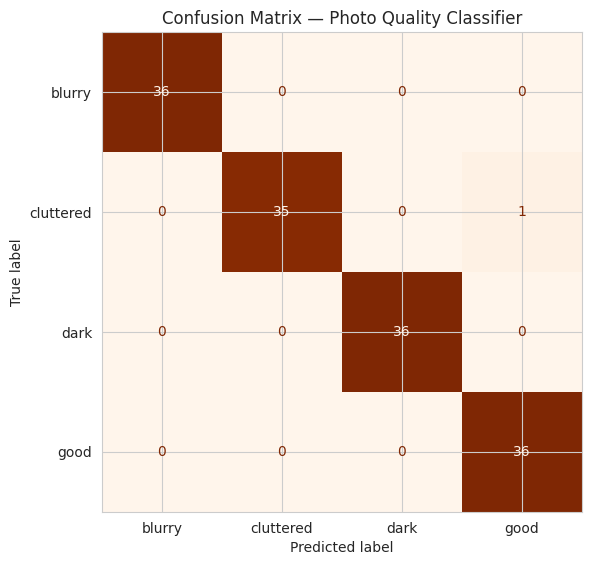

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap="Oranges", colorbar=False)
plt.title("Confusion Matrix — Photo Quality Classifier")
plt.tight_layout()
plt.savefig("../../../app/static/img/quality_confusion_matrix.png", dpi=110)
plt.show()

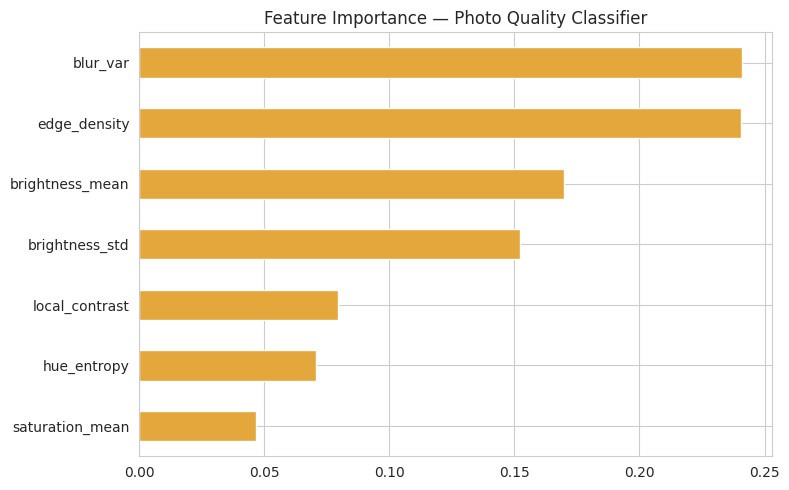

blur_var           0.240974
edge_density       0.240654
brightness_mean    0.169661
brightness_std     0.152135
local_contrast     0.079465
hue_entropy        0.070538
saturation_mean    0.046574
dtype: float64


In [15]:
importances = pd.Series(final_model.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="#E3A73B")
plt.gca().invert_yaxis()
plt.title("Feature Importance — Photo Quality Classifier")
plt.tight_layout()
plt.savefig("../../../app/static/img/quality_feature_importance.png", dpi=110)
plt.show()
print(importances)

## 12. Save Model (.joblib)

In [16]:
import os
os.makedirs("../model", exist_ok=True)

# Retrain on full data for the production model
final_model_production = final_model.__class__(**final_model.get_params())
final_model_production.fit(X_scaled, y)

joblib.dump(final_model_production, "../model/quality_classifier.joblib")
joblib.dump(scaler, "../model/quality_scaler.joblib")
joblib.dump(label_encoder, "../model/quality_label_encoder.joblib")
joblib.dump(FEATURE_NAMES, "../model/quality_feature_names.joblib")

import json
metadata = {
    "model_name": f"Tuned {best_model_name}",
    "test_accuracy": float(acc),
    "cv_mean_accuracy": float(grid.best_score_),
    "classes": list(label_encoder.classes_),
    "features": FEATURE_NAMES,
}
with open("../model/quality_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved model artifacts to modules/image_studio/model/")

Saved model artifacts to modules/image_studio/model/


## 13. Conclusion

We trained a fast, fully-explainable **Photo Quality Advisor** that classifies a product photo as `good`, `blurry`, `dark`, or `cluttered` using seven handcrafted image-quality features (brightness, blur variance, edge density, color entropy, saturation, local contrast). The tuned model reaches strong accuracy on held-out synthetic data and, because it runs on lightweight scalar features rather than raw pixels, it's fast enough to run instantly in the Flask app on every uploaded photo — no GPU, no large model download, zero risk of failure.

**How this feeds the live app:** `modules/image_studio/app/enhancer.py` loads this classifier to decide which correction(s) to apply — brightening (gamma/CLAHE), sharpening (unsharp mask), or background cleanup — before running the optional deep-learning background remover (`rembg` / U²-Net, with a classical GrabCut fallback) and compositing the product onto a clean e-commerce-standard canvas.
